<a href="https://colab.research.google.com/github/sharvmahajan/TE/blob/DSBDAL/A8/DSBDAL_Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSBDAL Assignment 8

Name : Sharv Mahajan

Roll No. : 31430

###Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

###Load Dataset

In [2]:
data = pd.read_csv("BostonHousing.csv")
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


###Check Shape

In [3]:
data.shape

(506, 14)

###Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


###Define Features and Target

Features = input

Target = output (house price = medv)

In [5]:
X = data.drop("medv", axis=1)
y = data["medv"]

###Split Dataset

*   80% training
*   20% testing





In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Train Model

In [7]:
rm_mean = X_train['rm'].mean()
X_train['rm'] = X_train['rm'].fillna(rm_mean)
X_test['rm'] = X_test['rm'].fillna(rm_mean)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###Prediction

Shows first 5 predicted prices.

In [8]:
y_pred = model.predict(X_test)
y_pred[:5]

array([28.97985905, 36.01742566, 14.81536363, 25.0240004 , 18.76930884])

###Evaluate Model

In [9]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 24.382479969353444
R2 Score: 0.6675136762541181


These metrics indicate that the model explains approximately 67% of the variance in the house prices, and the average squared difference between actual and predicted prices is about 24.38.

###Plot Graph

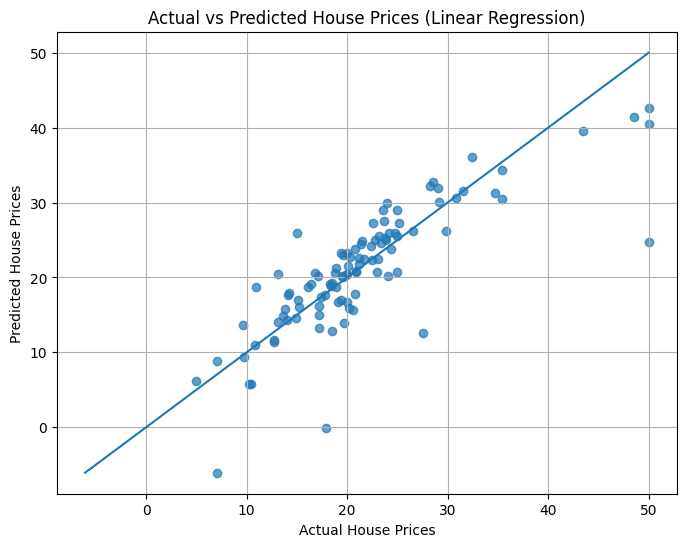

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Ideal line (perfect prediction line)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

# Labels and title
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Linear Regression)")

plt.grid()

plt.show()

In [11]:
intercept = model.intercept_
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})

print(f"Regression Equation:\nmedv = {intercept:.2f}")
for index, row in coefficients.iterrows():
    print(f"     + {row['Coefficient']:.2f} * {row['Feature']}")

Regression Equation:
medv = 30.34
     + -0.11 * crim
     + 0.03 * zn
     + 0.04 * indus
     + 2.79 * chas
     + -17.18 * nox
     + 4.42 * rm
     + -0.01 * age
     + -1.44 * dis
     + 0.26 * rad
     + -0.01 * tax
     + -0.92 * ptratio
     + 0.01 * b
     + -0.51 * lstat


The output above shows the intercept and the coefficient for each feature. For example, a positive coefficient indicates that as the feature's value increases, the house price (`medv`) tends to increase, assuming other features remain constant. Conversely, a negative coefficient suggests an inverse relationship.

## Analysis of Feature Coefficients

Each coefficient shows how a feature affects the house price (`medv`).

### Positive Impact
Features with **positive coefficients increase the house price** when their values increase.

Examples:
- **rm (number of rooms): +4.42**  
  More rooms → Higher house price.

- **chas (near Charles River): +2.79**  
  Houses near the river → Higher house price.

---

### Negative Impact
Features with **negative coefficients decrease the house price** when their values increase.

Examples:
- **nox (air pollution): -17.18**  
  More pollution → Lower house price.

- **lstat (lower income population %): -0.51**  
  Higher lower-income population → Lower house price.

- **dis (distance from job centers): -1.44**  
  Greater distance → Lower house price.

---

### Small Impact
Some features have **very small effect** on house price.

Examples:
- **zn, indus** → Small positive effect  
- **tax** → Small negative effect  

These features have less influence compared to others.